<a href="https://colab.research.google.com/github/KravitzLab/Barrett2024/blob/main/Figures/Murrell_2026_Fig4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Murrell 2026 Figure 4


Authors: Chantelle Murrell and Lex Kravitz<br>
Updated: 03/04/26

In [14]:
# @title Install libraries for Murrell2026 Figure 4{"run":"auto"}

import importlib.util
import subprocess
import sys

# Packages to ensure are installed (add others here if you like)
packages = {
    "fed3": "git+https://github.com/earnestt1234/fed3.git",
    "fed3bandit": "fed3bandit",
    "pingouin": "pingouin",
    "ipydatagrid": "ipydatagrid",
    "openpyxl": "openpyxl",
}

for name, source in packages.items():
    if importlib.util.find_spec(name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", source])

# ----------------------------
# Imports
# ----------------------------
# Standard library
import copy
import io
import math
import os
import re
import shutil
import tempfile
import threading
import time
import warnings
import zipfile
import glob
from datetime import datetime, timedelta
from os.path import basename, splitext

# Third-party
from ipydatagrid import DataGrid, TextRenderer
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML, Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import pingouin as pg
import fed3
import fed3.plot as fplot
import fed3bandit as f3b
from scipy.stats import f_oneway
import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.gridspec as gridspec
from google.colab import files
from tqdm.auto import tqdm
try:
    from google.colab import files as gfiles
except Exception:
    gfiles = None


# ----------------------------
# Configuration
# ----------------------------
warnings.filterwarnings("ignore")
plt.rcParams.update({'font.size': 12, 'figure.autolayout': True})
plt.rcParams['figure.figsize'] = [6, 4]
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("Packages installed and imports ready.")

Packages installed and imports ready.


In [15]:
# @title Import FED3 PR1 Data

from urllib.request import urlretrieve
import os, zipfile, shutil
import pandas as pd
import numpy as np

try:
    from google.colab import output as colab_output
    colab_output.enable_custom_widget_manager()
except Exception:
    pass

zip_url = "https://github.com/KravitzLab/Murrell2025/raw/refs/heads/main/Data/PR1.zip"
key_url = "https://github.com/KravitzLab/Murrell2025/raw/refs/heads/main/Data/Murrell2026_Key.csv"

zip_dir = "/content/Murrell2025_zipdata"
zip_path = os.path.join(zip_dir, "PR1.zip")
extract_root = os.path.join(zip_dir, "PR1_extracted")
key_path = os.path.join(zip_dir, "Murrell2026_Key.csv")

os.makedirs(zip_dir, exist_ok=True)

# download + unzip (fresh each run)
if os.path.exists(zip_path):
    os.remove(zip_path)
if os.path.isdir(extract_root):
    shutil.rmtree(extract_root)

print("Importing github.com/KravitzLab/Murrell2025/Data/PR1.zip ...")
urlretrieve(zip_url, zip_path)

os.makedirs(extract_root, exist_ok=True)
with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_root)

# if the zip contains a Bandit100 folder, use it; otherwise use extract_root
bandit_root = os.path.join(extract_root, "Bandit100")
local_parent_path = bandit_root if os.path.isdir(bandit_root) else extract_root

# load CSVs
feds, loaded_files, session_types = [], [], []

for dirpath, _, filenames in os.walk(local_parent_path):
    for file_name in sorted(filenames):
        if file_name.lower().endswith(".csv"):
            file_path = os.path.join(dirpath, file_name)
            strain_name = os.path.basename(os.path.dirname(file_path))

            df = fed3.load(file_path)
            df.name = file_name
            df["Strain"] = strain_name
            df["SourceFile"] = file_name

            feds.append(df)
            loaded_files.append(file_path)

            st = df["Session_Type"].dropna().astype(str)
            session_types.append(st.iloc[0] if len(st) else None)

print(f"Loaded {len(feds)} CSV files.")

# download + load key
urlretrieve(key_url, key_path)

key_df = pd.read_csv(key_path, encoding="utf-8-sig")
key_df["Mouse_ID"] = key_df["Mouse_ID"].astype(str).str.strip()

# match Mouse_ID by substring in filename base
def _base_lower(p):
    return os.path.splitext(os.path.basename(p))[0].lower()

files_df = pd.DataFrame({"filename": loaded_files, "Session_type": session_types})
files_df["_base"] = files_df["filename"].map(_base_lower)

mouse_ids = (
    key_df["Mouse_ID"]
    .dropna().astype(str).str.strip()
    .replace("", np.nan).dropna().unique().tolist()
)

rows = []
for fname, base in zip(files_df["filename"], files_df["_base"]):
    hits = [mid for mid in mouse_ids if mid.lower() in base]
    rows.append({"filename": fname, "Mouse_ID": hits[0] if len(hits) else None})

matched = pd.DataFrame(rows)

Key_Df = (
    files_df.drop(columns=["_base"])
    .merge(matched, on="filename", how="left")
    .merge(key_df.drop_duplicates("Mouse_ID"), on="Mouse_ID", how="left")
)

# display
grid = DataGrid(
    Key_Df.reset_index(drop=True),
    editable=True,
    selection_mode="cell",
    layout={"height": "420px"},
    base_row_size=28,
    base_column_size=120,
)
grid.default_renderer = TextRenderer(text_wrap=True)
display(grid)

Importing github.com/KravitzLab/Murrell2025/Data/PR1.zip ...
Loaded 136 CSV files.


DataGrid(auto_fit_params={'area': 'all', 'padding': 30, 'numCols': None}, base_column_size=120, base_row_size=…

In [16]:
#@title Figure 4A
Image(url='https://github.com/KravitzLab/Murrell2026/blob/main/Figures/Murrell_2026jpgs/Murrell_2026_Figure4_schematic.jpg?raw=true', width=300)

In [17]:
# @title Figure 4B Individual behaviour examples

assert 'Key_Df' in globals() and isinstance(Key_Df, pd.DataFrame), "Build/rematch Key_Df first."

# metadata_df = copy of Key_Df
metadata_df = Key_Df.copy().reset_index(drop=True)
if 'filename' in metadata_df.columns:
    metadata_df['filename'] = metadata_df['filename'].astype(str).map(os.path.basename)

# -------- Plotting Function --------
def plot_file(file_index):
    """
    Returns (fig, filename) for UI to display/save.
    Prints a message and returns (None, None) on errors.
    """
    # Safety check
    if 'feds' not in globals() or file_index >= len(feds):
        print(f"Index {file_index} is out of range (max {len(feds)-1 if 'feds' in globals() else 'N/A'}).")
        return None, None

    df = feds[file_index]
    # Keep only pellet rows, but don't mutate df
    pellet_df = df[df['Event'] == 'Pellet'].copy()
    if pellet_df.empty:
        print(f"No pellet events for file index {file_index}.")
        return None, None

    # Determine filename for title/return
    if 'loaded_files' in globals() and len(loaded_files) > file_index:
        raw_file = loaded_files[file_index]
    elif 'files' in globals() and len(files) > file_index:
        raw_file = files[file_index]
    else:
        raw_file = f"file_{file_index}"
    filename = os.path.basename(str(raw_file))

    # Match Mouse_ID from metadata, robust to path vs basename
    title_str = filename
    if 'filename' in metadata_df.columns:
        md_fn = metadata_df['filename'].astype(str).map(os.path.basename)
        hit = metadata_df.loc[md_fn == filename]
        if not hit.empty:
            match_row = hit.iloc[0]
            if 'Mouse_ID' in match_row and pd.notna(match_row['Mouse_ID']):
                title_str = f"{match_row['Mouse_ID']}"

    # Determine x-axis
    x_series = None
    x_is_datetime = isinstance(pellet_df.index, pd.DatetimeIndex)
    if x_is_datetime:
        x_series = pellet_df.index
    else:
        for col in ['Timestamp', 'Time', 'DateTime', 'Datetime', 'datetime']:
            if col in pellet_df.columns:
                ts = pd.to_datetime(pellet_df[col], errors='coerce')
                if ts.notna().any():
                    pellet_df['_x'] = ts
                    x_series = pellet_df['_x']
                    x_is_datetime = True
                    break
        if x_series is None:
            x_series = pellet_df.index  # fall back to index

    # Build figure (DO NOT show here)
    fig = plt.figure(figsize=(6, 4))
    ax = fig.add_subplot(111)

    hue_vals = pellet_df['Block_Pellet_Count'].clip(upper=40)
    sns.scatterplot(
        data=pellet_df,
        x=x_series,
        y='Block_Pellet_Count',
        hue=hue_vals,
        palette='spring',
        alpha=0.6,
        legend=False,
        ax=ax
    )

    # Night shading if datetime x
    if x_is_datetime:
        import datetime as dt
        night_start = dt.time(18, 0)  # 18:00
        night_end   = dt.time(6, 0)   # 06:00

        start_date = pd.to_datetime(pd.Series(x_series)).min().normalize()
        end_date   = pd.to_datetime(pd.Series(x_series)).max().normalize()

        # shade from each day's 18:00 to next day's 06:00
        for day in pd.date_range(start_date, end_date - pd.Timedelta(days=1)):
            start = pd.Timestamp.combine(day, night_start)
            end   = pd.Timestamp.combine(day + pd.Timedelta(days=1), night_end)
            ax.axvspan(start, end, color='gray', alpha=0.2)

        import matplotlib.dates as mdates
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
        ax.set_xlabel('')
    else:
        ax.set_xlabel('Index')
    ax.set_ylabel('Pellet Count in Block')
    ax.set_title(title_str)
    fig.tight_layout()

    # Return for UI to display/save later
    return fig, filename

# ---------- UI: single instance ----------
demand_ui = {}

def _sanitize_filename(s: str) -> str:
    return re.sub(r"[^A-Za-z0-9._-]+", "_", s)

# Slider bounds from number of feds (not files)
n_items = len(feds) if 'feds' in globals() else 1
slider = widgets.IntSlider(
    min=0, max=max(0, n_items-1), step=1, value=0,
    description="File", continuous_update=True
)

status = widgets.HTML()
out = widgets.Output()

def _update_plot(change=None):
    with out:
        out.clear_output(wait=True)
        fig, file = plot_file(slider.value)
        if fig is None:
            status.value = "<span style='color:#b00'>No figure to display.</span>"
            return
        display(fig)
        plt.close(fig)
        demand_ui["_last_fig"] = fig
        demand_ui["_last_file"] = file
        status.value = ""


slider.observe(_update_plot, names="value")


# Keep references so we can close them next run
box = widgets.HBox([slider])
demand_ui.update({"slider": slider, "out": out, "box": box})

# Display the controls and initial plot
display(box, status, out)
_update_plot()

HTML(value='')

Output()

In [18]:
# @title Analyse PR metrics
from scipy.optimize import curve_fit
from scipy.stats import ttest_ind
from tqdm.auto import tqdm
try:
    from tqdm.auto import tqdm as _tqdm
except Exception:
    try:
        # If user did `from tqdm import tqdm` earlier
        _tqdm = tqdm  # type: ignore[name-defined]
    except Exception:
        # Fallback: no-op iterator
        def _tqdm(x, **kwargs):
            return x
# --- Preconditions ---
assert 'metadata_df' in globals() and isinstance(metadata_df, pd.DataFrame), \
    "metadata_df not found. Build/rematch Key_Df and set metadata_df = Key_Df.copy() first."
assert 'feds' in globals() and isinstance(feds, (list, tuple)) and len(feds) > 0, \
    "No FED3 sessions found. Expecting a non-empty 'feds' list."

# ---------- Small helpers (merged + minimal PR utilities) ----------
def _basename(pathlike) -> str:
    s = str(pathlike).replace("\\", "/")
    return s.split("/")[-1]

def _to_num(s):
    return pd.to_numeric(s, errors="coerce")

def _count_events(df, label: str) -> int:
    if "Event" not in df.columns:
        return 0
    return int((df["Event"].astype(str) == label).sum())

def breakpoint_and_runs(df):
    """
    Merge of _breakpoint_stats(df) and _count_runs(df).
    Returns: (median_breakpoint, max_breakpoint, runs_count)
    - 'Breakpoint' is taken at the end of a block/run: current BPC > 0 and next BPC == 0
    - 'runs_count' is the number of such end-of-block events
    """
    if "Block_Pellet_Count" not in df.columns or df["Block_Pellet_Count"].empty:
        return np.nan, np.nan, 0

    bpc = _to_num(df["Block_Pellet_Count"])
    # end-of-block: positive now, zero next
    end_mask = (bpc > 0) & (bpc.shift(-1) == 0)
    end_vals = bpc[end_mask]

    med_bp = float(end_vals.median()) if len(end_vals) else np.nan
    max_bp = float(bpc.max()) if bpc.notna().any() else np.nan
    runs   = int(end_mask.sum())
    return med_bp, max_bp, runs

def _get_timestamp_series(df, ts_col="MM:DD:YYYY hh:mm:ss"):
    """Return a pandas Series of timestamps (never an Index)."""
    if ts_col in df.columns:
        ts = pd.to_datetime(df[ts_col], format="%Y-%m-%d %H:%M:%S", errors="coerce")
        return pd.Series(ts, index=df.index)
    for cand in ["DateTime", "Datetime", "Timestamp", "timestamp", "datetime"]:
        if cand in df.columns:
            ts = pd.to_datetime(df[cand], errors="coerce")
            return pd.Series(ts, index=df.index)
    idx = df.index
    if isinstance(idx, pd.DatetimeIndex):
        return pd.Series(idx, index=df.index)
    return pd.to_datetime(pd.Series(idx, index=df.index), errors="coerce")

def _estimate_daily_pellets(df):
    ts = _get_timestamp_series(df)
    valid_ts = ts.dropna()
    if valid_ts.size < 2:
        return np.nan
    duration_hours = (valid_ts.max() - valid_ts.min()).total_seconds() / 3600.0
    if duration_hours <= 0:
        return np.nan

    pellet_events = np.nan
    if "Pellet_Count" in df.columns and df["Pellet_Count"].notna().any():
        pc = pd.to_numeric(df["Pellet_Count"], errors="coerce")
        if pc.notna().any():
            diffs = pc.diff().fillna(0).clip(lower=0)
            pellet_events = float(diffs.sum())
            if pellet_events == 0 and pc.iloc[-1] >= pc.iloc[0]:
                pellet_events = float(pc.iloc[-1] - pc.iloc[0])

    if (pd.isna(pellet_events)) and ("Event" in df.columns):
        pellet_events = float((df["Event"].astype(str) == "Pellet").sum())

    if pd.isna(pellet_events):
        return np.nan
    return (pellet_events / duration_hours) * 24.0

# ---------- Step 4: normalize metadata_df ----------
md = metadata_df.copy()
# Normalize filename column to basename; accept either 'filename' or 'File'
if 'filename' in md.columns:
    md['filename'] = md['filename'].astype(str).map(_basename)
elif 'File' in md.columns:
    md['filename'] = md['File'].astype(str).map(_basename)
else:
    raise ValueError("metadata_df must contain a 'filename' or 'File' column.")

# Ensure Mouse_ID exists and is a clean string column
if 'Mouse_ID' in md.columns:
    md['Mouse_ID'] = md['Mouse_ID'].astype(str).str.strip()
else:
    md['Mouse_ID'] = np.nan

# ---------- Step 5: compute PR metrics for ALL files ----------
rows = []
for idx, c_df in enumerate(_tqdm(feds, desc="Computing PR metrics")):
    # Prefer DataFrame.name if present; otherwise synthesize a filename
    file_name = _basename(getattr(c_df, "name", f"File_{idx}"))

    # Core PR metrics (Pellet/Left/Right/Total/Accuracy/PokesPerPellet)
    pellets = _count_events(c_df, "Pellet")
    left    = _count_events(c_df, "Left")
    right   = _count_events(c_df, "Right")
    total   = left + right
    acc     = (left / total * 100.0) if total > 0 else np.nan
    ppp     = (total / pellets) if pellets > 0 else np.nan

    # Breakpoints + number of runs (merged helper)
    med_bp, max_bp, runs = breakpoint_and_runs(c_df)

    # Daily pellets estimate
    daily  = _estimate_daily_pellets(c_df)

    rows.append({
        "filename": file_name,
        "Left_Poke": left,
        "Right_Poke": right,
        "Total_Pokes": total,
        "Accuracy": acc,
        "PokesPerPellet": ppp,
        "MedianBreakPoint": med_bp,
        "Numberofblocks": runs,
        "daily pellets": daily,
    })

PRmetrics = pd.DataFrame(rows)
if PRmetrics.empty:
    display(HTML("<b style='color:#b00'>No files to analyze.</b>"))
    raise SystemExit

# keep this threshold; print when skipping
MIN_RUNS_PER_MOUSE = 1  # "runs" == Numberofblocks

# filename -> df (match how you named files earlier)
def _basename(pathlike):
    s = str(pathlike).replace("\\", "/")
    return s.split("/")[-1]

file_names = [_basename(getattr(df, "name", f"File_{i}")) for i, df in enumerate(feds)]
file_to_df = dict(zip(file_names, feds))

# filename -> Mouse_ID mapping from normalized md (we haven't merged it yet, but md is ready)
fname_to_mouse = md.set_index("filename")["Mouse_ID"].to_dict()

# total runs (blocks) per mouse from PRmetrics + md mapping
runs_tbl = (
    PRmetrics[["filename", "Numberofblocks"]]
    .assign(Mouse_ID=lambda d: d["filename"].map(fname_to_mouse))
)
runs_tbl["Numberofblocks"] = pd.to_numeric(runs_tbl["Numberofblocks"], errors="coerce").fillna(0).astype(int)

runs_per_mouse = runs_tbl.groupby("Mouse_ID", dropna=True)["Numberofblocks"].sum().to_dict()
keep_mice = {m for m, r in runs_per_mouse.items() if r >= MIN_RUNS_PER_MOUSE}
for m, r in runs_per_mouse.items():
    if m not in keep_mice:
        print(f"[{m}] skipped: only {r} blocks (< {MIN_RUNS_PER_MOUSE}).")

# build raw demand points per file -> roll up per mouse (no truncation, no min-bins)
raw_rows = []
for fn, df in file_to_df.items():
    mouse = fname_to_mouse.get(fn, None)
    if (mouse is None) or (mouse not in keep_mice):
        continue
    if {"Event", "Block_Pellet_Count"} - set(df.columns):
        print(f"[{mouse}] file {fn} missing Event/BPC columns; skipped.")
        continue

    pellets = df[df["Event"].astype(str) == "Pellet"].copy()
    if pellets.empty:
        print(f"[{mouse}] file {fn} has 0 pellet rows; skipped.")
        continue

    bpc = pd.to_numeric(pellets["Block_Pellet_Count"], errors="coerce")
    counts = (
        pellets.assign(Block_Pellet_Count=bpc)
        .dropna(subset=["Block_Pellet_Count"])
        .groupby("Block_Pellet_Count")
        .size()
    )
    if counts.empty:
        print(f"[{mouse}] file {fn} produced no valid price bins; skipped.")
        continue

    for price, cnt in counts.items():
        raw_rows.append({"Mouse_ID": mouse, "PricePaid": int(price), "PelletCount": int(cnt)})

demand_raw_df = pd.DataFrame(raw_rows)

# if nothing, set up empty demand metrics; otherwise fit
if demand_raw_df.empty:
    demand_metrics = pd.DataFrame(columns=[
        "Mouse_ID", "Demand_Q0_raw", "Demand_alpha_raw", "Demand_beta_raw",
        "Demand_alpha_norm", "Demand_beta_norm"
    ])
else:
    # collapse to per-mouse histogram
    demand_mouse = (demand_raw_df
                    .groupby(["Mouse_ID", "PricePaid"], as_index=False)["PelletCount"]
                    .sum())

    # normalization factor per mouse (baseline price -> Q=100)
    def _baseline_B(sub):
        if sub.empty:
            return np.nan
        mprice = sub["PricePaid"].min()
        return sub.loc[sub["PricePaid"] == mprice, "PelletCount"].mean()

    B = (demand_mouse.groupby("Mouse_ID")
         .apply(_baseline_B).rename("B").reset_index())
    B["q"] = 100.0 / B["B"]

    # Q-only normalization (keep FR requirement unscaled)
    normalized = (
        demand_mouse
        .merge(B[["Mouse_ID", "q"]], on="Mouse_ID", how="left")
        .assign(
            P_FR=lambda d: d["PricePaid"],             # FR requirement (unscaled)
            Q_norm=lambda d: d["PelletCount"] * d["q"] # normalize only quantity
        )
    )

    # models
    def loglog3(P, Q0, a, b):  # raw, free Q0
        return Q0 / (1.0 + (P / a) ** b)

    def loglogN(P, a, b):      # normalized Q with Q0 fixed to 100
        return 100.0 / (1.0 + (P / a) ** b)

    # --- fit per-mouse (RAW) ---
    raw_fit_rows = []
    for mouse, sub in demand_mouse.groupby("Mouse_ID"):
        P = sub["PricePaid"].to_numpy(dtype=float)
        Q = sub["PelletCount"].to_numpy(dtype=float)
        nuniq = np.unique(P).size
        if nuniq < 3:
            print(f"[{mouse}] demand fit skipped (raw): need ≥3 unique FR levels, have {nuniq}.")
            continue
        try:
            popt, _ = curve_fit(
                loglog3, P, Q,
                p0=[Q.max(), float(np.median(P)), 2.0],
                bounds=([1e-6, 1e-6, 1e-3], [np.inf, np.inf, 50.0]),
                maxfev=20000
            )
            raw_fit_rows.append({
                "Mouse_ID": mouse,
                "Demand_Q0_raw": float(popt[0]),
                "Demand_alpha_raw": float(popt[1]),
                "Demand_beta_raw": float(popt[2]),
            })
        except Exception as e:
            print(f"[{mouse}] demand curve fit failed (raw): {e}")

    demand_fit_raw = pd.DataFrame(raw_fit_rows)

    # --- fit per-mouse (Q-normalized, FR on x-axis) ---
    fr_fit_rows = []
    for mouse, sub in normalized.groupby("Mouse_ID"):
        P = sub["P_FR"].to_numpy(dtype=float)    # FR requirement (unscaled)
        Q = sub["Q_norm"].to_numpy(dtype=float)  # normalized quantity

        nuniq = np.unique(P).size
        if nuniq < 3:
            print(f"[{mouse}] demand fit skipped (norm-Q): need ≥3 unique FR levels, have {nuniq}.")
            continue
        try:
            popt, _ = curve_fit(
                loglogN, P, Q,
                p0=[float(np.median(P)), 2.0],
                bounds=([1e-6, 1e-3], [np.inf, 50.0]),
                maxfev=20000
            )
            fr_fit_rows.append({
                "Mouse_ID": mouse,
                "Demand_alpha_FR": float(popt[0]),  # alpha is now in FR units
                "Demand_beta_FR": float(popt[1]),
            })
        except Exception as e:
            print(f"[{mouse}] demand curve fit failed (norm-Q): {e}")

    demand_fit_fr = pd.DataFrame(fr_fit_rows)

    # --- combine demand metrics per mouse ---
    demand_metrics = demand_fit_raw.merge(demand_fit_fr, on="Mouse_ID", how="outer")

# ---------- Attach Mouse_ID (primary) from metadata_df, then merge all metadata ----------
# 1) Direct map filename -> Mouse_ID
mouse_map = md.set_index('filename')['Mouse_ID']
PRmetrics['Mouse_ID'] = PRmetrics['filename'].map(mouse_map)

# Attach demand metrics now that PRmetrics has Mouse_ID
PRmetrics = PRmetrics.merge(demand_metrics, on="Mouse_ID", how="left")

# 2) Fallback: substring match on known Mouse_IDs if still missing
if PRmetrics['Mouse_ID'].isna().any():
    def _file_base_lower(pathlike):
        return os.path.splitext(os.path.basename(str(pathlike)))[0].lower()

    known_ids = md['Mouse_ID'].dropna().unique().tolist()
    for i, row in PRmetrics.loc[PRmetrics['Mouse_ID'].isna()].iterrows():
        base = _file_base_lower(row['filename'])
        hits = [mid for mid in known_ids if str(mid).lower() in base]
        if len(hits) == 1:
            PRmetrics.at[i, 'Mouse_ID'] = hits[0]
        elif len(hits) > 1:
            longest = max(len(str(h)) for h in hits)
            best = [h for h in hits if len(str(h)) == longest]
            if len(best) == 1:
                PRmetrics.at[i, 'Mouse_ID'] = best[0]

# 3) Merge metadata: prefer Mouse_ID, fallback to filename if no Mouse_ID match
md_mouse_unique = md.drop_duplicates(subset=['Mouse_ID'], keep='first')
pm = PRmetrics.merge(md_mouse_unique, on='Mouse_ID', how='left', suffixes=('', '_md'))

needs_fallback = pm['Mouse_ID'].isna() | pm.filter(regex='_md$').isna().all(axis=1)
if needs_fallback.any():
    md_file_unique = md.drop_duplicates(subset=['filename'], keep='first')
    pm_fb = PRmetrics.loc[needs_fallback].merge(
        md_file_unique, on='filename', how='left', suffixes=('', '_md')
    )
    PRmetrics_merged = pd.concat([pm.loc[~needs_fallback], pm_fb], ignore_index=True)
else:
    PRmetrics_merged = pm
from IPython.display import display, HTML
try:
    from google.colab import files as gfiles
except Exception:
    gfiles = None

GROUP_COL = "Sex"
metrics = ["Accuracy", "MedianBreakPoint","Demand_Q0_raw", "Demand_alpha_FR", "Demand_beta_FR","daily pellets", "Total_Pokes",]
COLOR_MAP = {"F": "red", "M": "dodgerblue"}

def _norm_sex(x):
    s = str(x).strip().upper()
    if s in {"F", "FEMALE", "FEM"}: return "F"
    if s in {"M", "MALE"}: return "M"
    return "UNK"

def welch_p(a, b):
    a = pd.Series(a, dtype=float).dropna()
    b = pd.Series(b, dtype=float).dropna()
    if len(a) < 2 or len(b) < 2:
        return np.nan
    return float(ttest_ind(a, b, equal_var=False, nan_policy="omit").pvalue)

# --- Preconditions ---
if "PRmetrics_merged" not in globals() or PRmetrics_merged is None or PRmetrics_merged.empty:
    raise RuntimeError("PRmetrics_merged is missing/empty. Run the metrics cell first.")

bm = PRmetrics_merged.copy()

# --- Ensure Sex (merge from metadata_df if needed) ---
if GROUP_COL not in bm.columns or bm[GROUP_COL].isna().all():
    if "metadata_df" not in globals() or metadata_df is None or metadata_df.empty:
        raise RuntimeError("Sex not found in PRmetrics_merged and metadata_df is missing/empty.")
    meta = metadata_df.copy()

    def _find_col(df, name):
        lc = {str(c).strip().lower(): c for c in df.columns}
        return lc.get(name.lower(), None)

    meta_sex = _find_col(meta, "Sex")
    if meta_sex is None:
        raise RuntimeError("metadata_df does not contain a 'Sex' column (case-insensitive).")

    meta_mouse = _find_col(meta, "Mouse_ID")
    bm_mouse   = _find_col(bm, "Mouse_ID")

    merged = None
    if meta_mouse is not None and bm_mouse is not None:
        meta_key = meta[[meta_mouse, meta_sex]].copy()
        meta_key.columns = ["Mouse_ID", "Sex"]
        meta_key["Mouse_ID"] = meta_key["Mouse_ID"].astype(str).str.strip()
        meta_key = meta_key.dropna(subset=["Mouse_ID"]).drop_duplicates("Mouse_ID")

        bm["Mouse_ID"] = bm[bm_mouse].astype(str).str.strip()
        merged = bm.merge(meta_key, on="Mouse_ID", how="left")

    if merged is None or merged["Sex"].isna().all():
        if "filename" not in bm.columns:
            if "File" in bm.columns:
                bm["filename"] = bm["File"].astype(str)
            else:
                raise RuntimeError("Need either Mouse_ID or filename/File in Bandit100_metrics to merge Sex.")
        if "filename" not in meta.columns:
            raise RuntimeError("Cannot fallback merge: metadata_df has no filename column.")

        bm["file_base"]   = bm["filename"].astype(str).apply(lambda p: os.path.basename(p))
        meta["file_base"] = meta["filename"].astype(str).apply(lambda p: os.path.basename(p))

        meta_key = meta[["file_base", meta_sex]].copy()
        meta_key.columns = ["file_base", "Sex"]
        meta_key = meta_key.dropna(subset=["file_base"]).drop_duplicates("file_base")

        merged = bm.merge(meta_key, on="file_base", how="left").drop(columns=["file_base"])

    bm = merged

#Create Long_Df for plotting
bm[GROUP_COL] = bm[GROUP_COL].apply(_norm_sex)
bm = bm[bm[GROUP_COL].isin(["F", "M"])].copy()
if bm.empty:
    raise RuntimeError("After merging/normalizing Sex, no rows with Sex in {F, M} were found.")

# --- Long format (your old way) ---
value_vars = [m for m in metrics if m in bm.columns]
if not value_vars:
    raise RuntimeError("None of the expected metric columns were found in Bandit100_metrics.")

id_vars = [c for c in ["filename", "Mouse_ID", "Strain", GROUP_COL] if c in bm.columns]
long_df = bm.melt(id_vars=id_vars, value_vars=value_vars, var_name="metric", value_name="value")

groups = [g for g in ["F", "M"] if g in long_df[GROUP_COL].unique()]
if len(groups) < 2:
    raise RuntimeError(f"Need both F and M present to compare; found: {groups}")

# --- Precompute raw p-values for ALL metrics (once) ---
raw_pvals = {}
for metric in metrics:
    if metric not in value_vars:
        raw_pvals[metric] = np.nan
        continue
    dfm = long_df[long_df["metric"] == metric].dropna(subset=["value"])
    a = dfm.loc[dfm[GROUP_COL] == groups[0], "value"]
    b = dfm.loc[dfm[GROUP_COL] == groups[1], "value"]
    raw_pvals[metric] = welch_p(a, b)



csv_name = f"PR1_metrics.csv"

# Optional download button (Colab)
btn = widgets.Button(description=f"Download {os.path.basename(csv_name)}", icon="download")
status = widgets.HTML()
def _dl(_):
    try:
        status.value = f"Starting download: <code>{os.path.basename(csv_name)}</code>…"
        gfiles.download(csv_name)
    except Exception:
        status.value = f"Saved locally at <code>{csv_name}</code>."
display(btn, status)
btn.on_click(_dl)

Computing PR metrics:   0%|          | 0/136 [00:00<?, ?it/s]

Button(description='Download PR1_metrics.csv', icon='download', style=ButtonStyle())

HTML(value='')

In [19]:
# @title Plot individual demand curves
try:
    if isinstance(globals().get("demand_ui"), dict):
        for k in ["slider", "save_btn", "status", "out", "box"]:
            w = demand_ui.get(k)
            if hasattr(w, "close"):
                w.close()
        del demand_ui
except Exception:
    pass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from ipywidgets import interact, IntSlider
from IPython.display import clear_output
from matplotlib.lines import Line2D
import matplotlib.patheffects as pe
from matplotlib.colors import LogNorm, Normalize


# ---------- Build normalized_demand_df if missing ----------
def _basename(p):
    s = str(p).replace("\\", "/")
    return s.split("/")[-1]

if "normalized_demand_df" not in globals() or not isinstance(globals().get("normalized_demand_df"), pd.DataFrame) or globals()["normalized_demand_df"].empty:
    assert 'feds' in globals() and isinstance(feds, (list, tuple)) and len(feds) > 0, \
        "Need `feds` (list of FED3 DataFrames) to derive normalized_demand_df."

    file_names = [_basename(getattr(df, "name", f"File_{i}")) for i, df in enumerate(feds)]
    file_to_df = dict(zip(file_names, feds))

    rows = []
    for fn, df in file_to_df.items():
        if {"Event", "Block_Pellet_Count"} - set(df.columns):
            continue
        pellets = df[df["Event"].astype(str) == "Pellet"].copy()
        if pellets.empty:
            continue
        bpc = pd.to_numeric(pellets["Block_Pellet_Count"], errors="coerce")
        counts = (
            pellets.assign(Block_Pellet_Count=bpc)
                   .dropna(subset=["Block_Pellet_Count"])
                   .groupby("Block_Pellet_Count")
                   .size()
        )
        for price, cnt in counts.items():
            rows.append({"File": str(fn), "PricePaid": int(price), "PelletCount": int(cnt)})

    normalized_demand_df = pd.DataFrame(rows)
    if not normalized_demand_df.empty:
        keep = normalized_demand_df.groupby("File")["PricePaid"].nunique()
        normalized_demand_df = normalized_demand_df[
            normalized_demand_df["File"].isin(keep[keep >= 3].index)
        ].reset_index(drop=True)

# Preconditions
if "normalized_demand_df" not in globals() or not isinstance(normalized_demand_df, pd.DataFrame) or normalized_demand_df.empty:
    raise RuntimeError("normalized_demand_df is missing or empty. Expect columns: File, PricePaid, PelletCount.")

for col in ["File", "PricePaid", "PelletCount"]:
    if col not in normalized_demand_df.columns:
        raise RuntimeError(f"normalized_demand_df must contain '{col}'")

# ---------- Prepare data (Q-only normalization) ----------
data = normalized_demand_df.copy()
data["File"]        = data["File"].astype(str)
data["PricePaid"]   = pd.to_numeric(data["PricePaid"], errors="coerce")
data["PelletCount"] = pd.to_numeric(data["PelletCount"], errors="coerce")
data = data.dropna(subset=["PricePaid", "PelletCount"])

def _baseline_B(sub):
    return sub.loc[sub["PricePaid"].eq(sub["PricePaid"].min()), "PelletCount"].mean()

B_by_file = data.groupby("File", as_index=True).apply(_baseline_B).rename("B")
q_by_file = (100.0 / B_by_file).rename("q")

data = data.merge(q_by_file, left_on="File", right_index=True, how="left")
data["Q_norm"] = data["PelletCount"] * data["q"]

files = sorted(data["File"].unique().tolist())

# Optional mouse labels
fname_to_mouse = {}
if "metadata_df" in globals() and isinstance(metadata_df, pd.DataFrame):
    md_tmp = metadata_df.copy()
    if "filename" in md_tmp.columns and "Mouse_ID" in md_tmp.columns:
        md_tmp["filename"] = md_tmp["filename"].astype(str).apply(lambda p: p.split("/")[-1])
        fname_to_mouse = md_tmp.set_index("filename")["Mouse_ID"].astype(str).to_dict()

# ---------- Model ----------
def log_logistic_norm(P, alpha, beta):
    return 100.0 / (1.0 + (P / alpha)**beta)

# ---------- Plotter (returns fig; does not call plt.show) ----------
def plot_mouse(idx: int):
    if len(files) == 0:
        raise RuntimeError("No files in data.")
    if not (0 <= idx < len(files)):
        raise RuntimeError(f"Out-of-range index {idx} for {len(files)} files.")

    file = files[idx]
    sub = data[data["File"] == file].copy().sort_values("PricePaid")

    FR = sub["PricePaid"].to_numpy(dtype=float)
    Qn = sub["Q_norm"].to_numpy(dtype=float)

    # Fit in FR space
    alpha_FR = beta_FR = np.nan
    if np.isfinite(FR).any() and np.isfinite(Qn).any():
        try:
            alpha0_fr = float(np.nanmedian(FR))
            popt_fr, _ = curve_fit(
                log_logistic_norm, FR, Qn,
                p0=[max(alpha0_fr, 1.0), 2.0],
                bounds=([1e-6, 1e-3], [np.inf, 50.0]),
                maxfev=20000
            )
            alpha_FR, beta_FR = [float(p) for p in popt_fr]
        except Exception:
            pass

    # Figure
    fig, ax = plt.subplots(figsize=(8, 5))


    # choose bounds from your finite, positive FR values
    FR_pos = FR[np.isfinite(FR) & (FR > 0)]
    vmin = float(np.nanmin(FR_pos)) if FR_pos.size else 1.0
    vmax = float(np.nanmax(FR_pos)) if FR_pos.size else 100.0

    # Log-normalize so equal ratios get equal color steps (matches log x-axis)
    norm = LogNorm(vmin=vmin, vmax=vmax)


    sc = ax.scatter(FR, Qn, c=FR, cmap="spring", norm=norm, s=30, edgecolor="none", alpha=0.9)


    FR_pos = FR[np.isfinite(FR) & (FR > 0)]
    xmin = float(np.nanmin(FR_pos)) if FR_pos.size else 1.0
    xmin = max(1.0, xmin)
    xmax_data = float(np.nanmax(FR_pos)) if FR_pos.size else 100.0
    xmax = max(100.0, xmax_data)
    if xmax <= xmin:
        xmax = xmin * 1.5
    ax.set_xlim(xmin, xmax)
    ax.set_xscale("log")

    if np.isfinite(alpha_FR) and np.isfinite(beta_FR):
        Pfit = np.logspace(np.log10(xmin), np.log10(xmax), 400)
        Qfit = log_logistic_norm(Pfit, alpha_FR, beta_FR)
        ax.plot(Pfit, Qfit, linewidth=2)

        ax.vlines(alpha_FR, ymin=0, ymax=50, linestyle="--", linewidth=1.5)
        ax.scatter([alpha_FR], [50], zorder=5)
        ax.annotate(
            rf"$\alpha_{{FR}}$ = {alpha_FR:.3g}",
            xy=(alpha_FR, 50),
            xytext=(8, 8), textcoords="offset points",
            fontsize=11, ha="left", va="bottom",
            path_effects=[pe.withStroke(linewidth=2, foreground="white", alpha=0.7)]
        )

        dQdP_alpha = -(100.0 * beta_FR) / (4.0 * alpha_FR)
        dx = alpha_FR * 0.2
        x1, x2 = alpha_FR - dx/2.0, alpha_FR + dx/2.0
        y1 = 50 + dQdP_alpha * (x1 - alpha_FR)
        y2 = 50 + dQdP_alpha * (x2 - alpha_FR)
        ax.plot([x1, x2], [y1, y2], linewidth=4)
        xm, ym = (x1 + x2) / 2.0, (y1 + y2) / 2.0
        ax.annotate(
            rf"$\beta_{{FR}}$ = {beta_FR:.3g}",
            xy=(xm, ym), xytext=(8, 0), textcoords="offset points",
            fontsize=11, ha="left", va="center",
            path_effects=[pe.withStroke(linewidth=2, foreground="white", alpha=0.7)]
        )

    title = fname_to_mouse.get(file, None) or os.path.basename(str(file))
    ax.set_title(str(title))
    ax.set_xlabel("Food Price (FR)")
    ax.set_ylabel("Consumption")
    ax.set_yticks(np.arange(0, 101, 20))
    ax.set_ylim(0, 105)

    fr_ticks = np.array([1, 5, 10, 20, 30, 50, 75, 100], dtype=float)
    fr_ticks = fr_ticks[(fr_ticks >= xmin) & (fr_ticks <= xmax)]
    if fr_ticks.size:
        ax.set_xticks(fr_ticks)
        ax.set_xticklabels([str(int(fr)) for fr in fr_ticks])
        for fr in fr_ticks:
            ax.axvline(fr, alpha=0.12, lw=1, zorder=0)

    ax.grid(False)
    fig.tight_layout()
    return fig, file

# ---------- UI: single instance ----------
demand_ui = {}

def _sanitize_filename(s: str) -> str:
    return re.sub(r"[^A-Za-z0-9._-]+", "_", s)

slider = widgets.IntSlider(
    min=0, max=max(0, len(files)-1), step=1, value=0,
    description="File", continuous_update=True
)
save_btn = widgets.Button(description="Save PDF")
status = widgets.HTML()
out = widgets.Output()

def _update_plot(change=None):
    with out:
        out.clear_output(wait=True)
        fig, file = plot_mouse(slider.value)
        display(fig)      # show exactly one figure
        plt.close(fig)    # close backend handle to prevent accumulation
        demand_ui["_last_fig"] = fig
        demand_ui["_last_file"] = file
        status.value = "" # clear old status

def _save_pdf(_):
    fig = demand_ui.get("_last_fig")
    file = demand_ui.get("_last_file", "figure")
    if fig is None:
        status.value = "<span style='color:#b00'>No figure to save.</span>"
        return
    base = _sanitize_filename(os.path.splitext(os.path.basename(str(file)))[0])
    fname = f"demand_{base}_{datetime.now():%Y%m%d_%H%M%S}.pdf"
    # Save from the stored fig object; even though we closed the backend handle,
    # the Figure instance retains its artists and can still be saved.
    fig.savefig(fname, format="pdf", bbox_inches="tight")
    if gfiles is not None:
        status.value = f"Preparing download: <code>{fname}</code>…"
        gfiles.download(fname)
    else:
        status.value = f"Saved locally at <code>{os.path.abspath(fname)}</code>."

slider.observe(_update_plot, names="value")
save_btn.on_click(_save_pdf)

# Keep references so we can close them next run
box = widgets.HBox([slider, save_btn])
demand_ui.update({"slider": slider, "save_btn": save_btn, "status": status, "out": out, "box": box})

# Initial render
_update_plot()
display(box)
display(status)
display(out)

HTML(value='')

Output()

,F_n,F_mean±SEM,M_n,M_mean±SEM
metric,,,,
Accuracy,62,79.849 ± 0.623,74,83.038 ± 0.564
MedianBreakPoint,62,9.137 ± 0.543,74,9.486 ± 0.722
Demand_Q0_raw,62,19.929 ± 0.775,74,20.486 ± 0.724
Demand_alpha_FR,62,10.166 ± 0.560,74,10.216 ± 0.706
Demand_beta_FR,62,2.010 ± 0.057,74,2.076 ± 0.062


Bonferroni Corrected p-values (Female vs. Male comparison):

- Accuracy: p = 0.0011
- MedianBreakPoint: p = 1.0000
- Demand_Q0_raw: p = 1.0000
- Demand_alpha_FR: p = 1.0000
- Demand_beta_FR: p = 1.0000



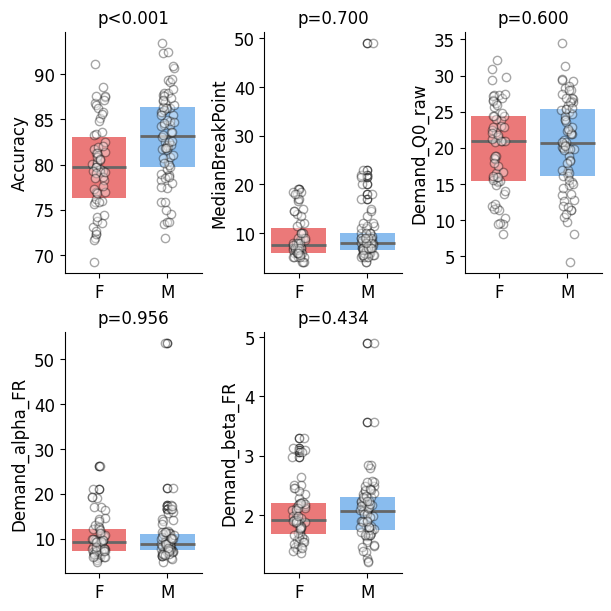

In [20]:
#@title Plot Female vs Male

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from statsmodels.stats.multitest import multipletests

def plot_metrics(
    long_df,
    metrics_subset,
    group_col="Sex",
    groups=("F", "M"),
    color_map=None,
    raw_pvals=None,
    bonferroni_metrics=None,
    ncols=3,
    figsize=None,
):
    df_plot = long_df[long_df["metric"].isin(metrics_subset)].copy()

    # ---- summary table for THIS subset only ----
    summary_long = (
        df_plot.dropna(subset=["value"])
              .groupby(["metric", group_col])["value"]
              .agg(n="count", mean="mean", sem="sem")
              .reset_index()
    )
    summary_table = summary_long.pivot(index="metric", columns=group_col, values=["n", "mean", "sem"])

    col_order = []
    for stat in ["n", "mean", "sem"]:
        for g in groups:
            if (stat, g) in summary_table.columns:
                col_order.append((stat, g))
    summary_table = summary_table[col_order]
    summary_table.columns = [f"{g}_{stat}" for stat, g in summary_table.columns]

    for g in groups:
        if f"{g}_mean" in summary_table.columns and f"{g}_sem" in summary_table.columns:
            m = summary_table[f"{g}_mean"]
            s = summary_table[f"{g}_sem"]
            summary_table[f"{g}_mean±SEM"] = np.where(
                m.notna(),
                m.map(lambda x: f"{x:.3f}") + " ± " + s.map(lambda x: f"{x:.3f}"),
                np.nan
            )

    keep_cols = []
    for g in groups:
        if f"{g}_n" in summary_table.columns:
            summary_table[f"{g}_n"] = summary_table[f"{g}_n"].astype("Int64")
            keep_cols.append(f"{g}_n")
        if f"{g}_mean±SEM" in summary_table.columns:
            keep_cols.append(f"{g}_mean±SEM")

    summary_table = summary_table.loc[metrics_subset, keep_cols]

    display(
        summary_table.style
            .format({c: "{:d}" for c in summary_table.columns if c.endswith("_n")})
            .set_caption("")
    )

    # ---- Bonferroni only for requested metrics ----
    if bonferroni_metrics:
        bonferroni_metrics = [m for m in bonferroni_metrics if m in metrics_subset]
        if bonferroni_metrics:
            bonf_raw = [raw_pvals.get(m, np.nan) for m in bonferroni_metrics]
            finite_mask = [np.isfinite(p) for p in bonf_raw]

            print("Bonferroni Corrected p-values (Female vs. Male comparison):\n")
            if any(finite_mask):
                bonf_names = [m for m, ok in zip(bonferroni_metrics, finite_mask) if ok]
                bonf_vals  = [p for p, ok in zip(bonf_raw, finite_mask) if ok]
                _, p_bonf, _, _ = multipletests(bonf_vals, alpha=0.05, method="bonferroni")
                bonf_map = dict(zip(bonf_names, p_bonf))

                for m in bonferroni_metrics:
                    p = bonf_map.get(m, np.nan)
                    print(f"- {m}: p = {p:.4f}" if np.isfinite(p) else f"- {m}: p = NA (Insufficient data)")
            else:
                for m in bonferroni_metrics:
                    print(f"- {m}: p = NA (Insufficient data)")
            print()

    # ---- plotting ----
    if color_map is None:
        color_map = {g: "0.7" for g in groups}
    pal = {g: color_map[g] for g in groups if g in color_map}

    n = len(metrics_subset)
    nrows = int(np.ceil(n / ncols))
    if figsize is None:
        figsize = (6, 3.0 * nrows)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()

    for i, metric in enumerate(metrics_subset):
        ax = axes[i]
        dfm = df_plot[df_plot["metric"] == metric].dropna(subset=["value"])

        sns.boxplot(
            data=dfm, x=group_col, y="value",
            order=list(groups), palette=pal,
            ax=ax, linewidth=0,
            whiskerprops=dict(linewidth=0),
            capprops=dict(linewidth=0),
            medianprops=dict(color="0.4", linewidth=2),
        )
        for patch in ax.patches:
            patch.set_alpha(0.6)

        sns.stripplot(
            data=dfm, x=group_col, y="value",
            order=list(groups),
            color="white", edgecolor="black",
            linewidth=1, size=6,
            alpha=0.35, jitter=True, ax=ax
        )

        p_raw = raw_pvals.get(metric, np.nan) if raw_pvals is not None else np.nan
        label = "p<0.001" if np.isfinite(p_raw) and p_raw < 0.001 else (f"p={p_raw:.3f}" if np.isfinite(p_raw) else "p=NA")
        ax.set_title("")
        ax.set_xlabel("")
        ax.set_ylabel(metric, fontsize=12)
        ax.text(0.5, 1.02, label, transform=ax.transAxes, ha="center", va="bottom")
        sns.despine(ax=ax)

    for j in range(n, len(axes)):
        axes[j].set_axis_off()


_ = plot_metrics(
long_df=long_df,
metrics_subset=metrics[:5],
group_col=GROUP_COL,
groups=groups,
color_map=COLOR_MAP,
raw_pvals=raw_pvals,
bonferroni_metrics=metrics[:5],
ncols=3
)




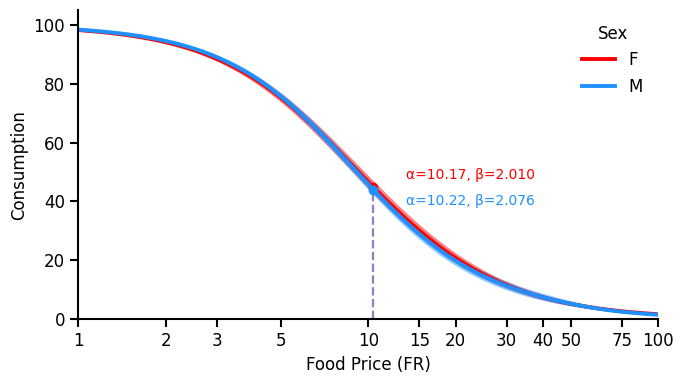

In [21]:
#@title Demand curves: Female vs Male

import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import sem
from datetime import datetime

# Optional Colab download
try:
    from google.colab import files as colab_files
except Exception:
    colab_files = None

# -----------------------
# Config
# -----------------------
GROUP_COL = "Sex"
COLOR_MAP = {"F": "red", "M": "dodgerblue"}

ALPHA_FILL = 0.22
LINE_W = 2.8

P_MIN = 1.0
N_GRID = 120
FALLBACK_MAX_P = 128
X_LIM = (1, 100)  # match your old plot style

# -----------------------
# Preconditions
# -----------------------
if (
    "PRmetrics_merged" not in globals()
    or not isinstance(PRmetrics_merged, pd.DataFrame)
    or PRmetrics_merged.empty
):
    raise RuntimeError("PRmetrics_merged not found/empty. Run the PR analysis cell first.")

bm = PRmetrics_merged.copy()

alpha_col = "Demand_alpha_FR"
beta_col  = "Demand_beta_FR"

missing = [c for c in [GROUP_COL, "Mouse_ID", alpha_col, beta_col] if c not in bm.columns]
if missing:
    raise RuntimeError(f"PRmetrics_merged is missing required columns: {missing}")

# -----------------------
# Normalize Sex to F/M/UNK
# -----------------------
def _norm_sex(x):
    s = str(x).strip().upper()
    if s in {"F", "FEMALE", "FEM"}: return "F"
    if s in {"M", "MALE"}: return "M"
    return "UNK"

bm[GROUP_COL] = bm[GROUP_COL].apply(_norm_sex)

# Keep only F/M
bm = bm[bm[GROUP_COL].isin(["F", "M"])].copy()
if bm.empty:
    raise RuntimeError("After normalizing Sex, no rows with Sex in {F, M} were found.")

# -----------------------
# Collapse to one row per mouse (important!)
# PRmetrics_merged can have multiple rows per mouse (files/sessions),
# so we take the first non-null alpha/beta per mouse.
# -----------------------
bm["Mouse_ID"] = bm["Mouse_ID"].astype(str).str.strip()

mouse_tbl = (
    bm.sort_values([GROUP_COL, "Mouse_ID"])
      .groupby(["Mouse_ID"], as_index=False)
      .agg({
          GROUP_COL: "first",
          alpha_col: "first",
          beta_col: "first",
      })
)

# Keep valid params only
mouse_tbl[alpha_col] = pd.to_numeric(mouse_tbl[alpha_col], errors="coerce")
mouse_tbl[beta_col]  = pd.to_numeric(mouse_tbl[beta_col], errors="coerce")
mouse_tbl = mouse_tbl.dropna(subset=[alpha_col, beta_col])
mouse_tbl = mouse_tbl[(mouse_tbl[alpha_col] > 0) & (mouse_tbl[beta_col] > 0)]

if mouse_tbl.empty:
    raise RuntimeError("No mice with valid Demand_alpha_FR and Demand_beta_FR were found.")

# -----------------------
# Price grid
# -----------------------
maxP_candidates = []

max_alpha = mouse_tbl[alpha_col].dropna().max()
if pd.notna(max_alpha):
    maxP_candidates.append(float(max_alpha) * 8.0)

if "demand_raw_df" in globals() and isinstance(demand_raw_df, pd.DataFrame) and "PricePaid" in demand_raw_df.columns:
    try:
        maxP_candidates.append(int(pd.to_numeric(demand_raw_df["PricePaid"], errors="coerce").max()))
    except Exception:
        pass

maxP = int(max(maxP_candidates) if maxP_candidates else FALLBACK_MAX_P)
maxP = max(maxP, int(P_MIN) + 1)

price_grid = np.unique(np.logspace(np.log10(max(P_MIN, 1.0)), np.log10(maxP), N_GRID))

def predict_Q(P, alpha, beta):
    P = np.asarray(P, dtype=float)
    return 100.0 / (1.0 + (P / alpha) ** beta)

# -----------------------
# Plot
# -----------------------
groups = [g for g in ["F", "M"] if g in mouse_tbl[GROUP_COL].unique()]
if len(groups) < 2:
    raise RuntimeError(f"Need both F and M present; found: {groups}")

fig, ax = plt.subplots(figsize=(7, 4))

stat_rows = []

for gi, g in enumerate(groups):
    sub = mouse_tbl[mouse_tbl[GROUP_COL] == g].copy()
    if sub.empty:
        continue

    alphas = sub[alpha_col].to_numpy(dtype=float)
    betas  = sub[beta_col].to_numpy(dtype=float)

    # Predict each mouse curve on the same grid
    Qs = np.vstack([predict_Q(price_grid, a, b) for a, b in zip(alphas, betas)])
    mean_Q = np.nanmean(Qs, axis=0)
    sem_Q  = sem(Qs, axis=0, nan_policy="omit")

    color = COLOR_MAP.get(g, "black")

    a_mean, a_sem = float(np.mean(alphas)), float(sem(alphas))
    b_mean, b_sem = float(np.mean(betas)),  float(sem(betas))

    # alpha marker at nearest grid point
    ix = int(np.argmin(np.abs(price_grid - a_mean)))
    x_alpha = float(price_grid[ix])
    y_alpha = float(mean_Q[ix])

    # curve + SEM band
    ax.plot(price_grid, mean_Q, label=g, color=color, linewidth=LINE_W)
    ax.fill_between(
        price_grid, mean_Q - sem_Q, mean_Q + sem_Q,
        alpha=0.5, edgecolor="none", linewidth=0, facecolor=color
    )

    # dashed vline + dot at alpha
    ax.vlines(x_alpha, 0, y_alpha, linestyle="--", linewidth=1.6, color=color, alpha=0.5)
    ax.plot(x_alpha, y_alpha, "o", color=color, markersize=6)

    # annotation (alternate up/down)
    text_x = x_alpha * 1.3
    vertical_offset = 4
    direction = 1 if gi % 2 == 0 else -1
    text_y = y_alpha + direction * vertical_offset
    ax.text(
        text_x, text_y,
        rf"α={a_mean:.2f}, β={b_mean:.3f}",
        color=color, fontsize=10, ha="left", va="center"
    )

    stat_rows.append({
        "Group": g,
        "N_mice": int(sub["Mouse_ID"].nunique()),
        "alpha_mean": a_mean, "alpha_sem": a_sem,
        "beta_mean": b_mean,  "beta_sem": b_sem,
    })

# Axes styling (match your original)
ax.set_xscale("log")
ax.set_xlabel("Food Price (FR)")
ax.set_ylabel("Consumption")

ax.set_yticks(np.arange(0, 101, 20))
ax.set_ylim(0, 105)
ax.set_xlim(*X_LIM)

ticks = np.array([1,2,3,5,10,15,20,30,40,50,75,100], float)
ax.set_xticks(ticks)
ax.set_xticklabels([str(int(x)) for x in ticks])
ax.minorticks_off()
ax.set_title("")
ax.spines["left"].set_position(("data", 1))
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.tick_params(axis="both", which="both", width=1.5, length=6)

ax.legend(title="Sex", frameon=False)
plt.tight_layout()
plt.show()

# Below is additional information not shown in Figure 4

,F_n,F_mean±SEM,M_n,M_mean±SEM
metric,,,,
daily pellets,62,117.008 ± 3.634,74,118.716 ± 2.229
Total_Pokes,62,3528.081 ± 167.868,74,3663.270 ± 180.922


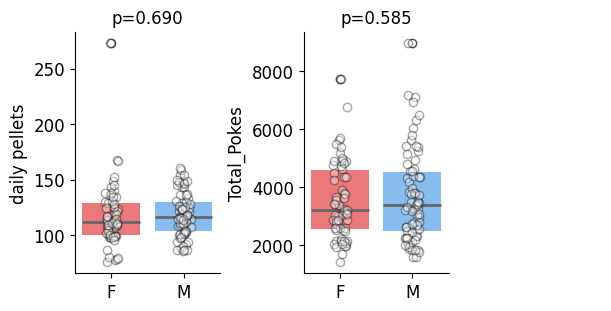

In [22]:
 #@title Pellets, Total pokes and Pellets retrieval time.
_ = plot_metrics(
    long_df=long_df,
    metrics_subset=metrics[5:],
    group_col=GROUP_COL,
    groups=groups,
    color_map=COLOR_MAP,
    raw_pvals=raw_pvals,
    bonferroni_metrics=[],
    ncols=3
)